pip install pandas scikit-learn matplotlib seaborn

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [11]:
# Dataset URL

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

# Load Dataset

df = pd.read_csv(url)

print("Successfully Loaded Dataset\n")

# Display First 5 Rows

print("First 5 Rows of Dataset:\n")

print(df.head())


# Display Dataset Information

print("\nDataset Information:\n")

print(df.info())

Successfully Loaded Dataset

First 5 Rows of Dataset:

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [12]:
# Features

X = df.iloc[:, :-1]

# Target Variable

y = df.iloc[:, -1]

print("\nFeatures:\n")

print(X.head())

print("\nTarget Variable:\n")

print(y.head())


Features:

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target Variable:

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDataset Split Completed")

print("\nShapes of Datasets:")

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)


Dataset Split Completed

Shapes of Datasets:
X_train shape : (120, 4)
X_test shape  : (30, 4)
y_train shape : (120,)
y_test shape  : (30,)


Create Naive Bayes Model

In [14]:
# Create Gaussian Naive Bayes Model

gnb_model = GaussianNB()

# Train Model

gnb_model.fit(X_train, y_train)

print("\nGaussian Naive Bayes Model Trained Successfully")


Gaussian Naive Bayes Model Trained Successfully


In [15]:
# Predict Test Data

y_pred_gaussian = gnb_model.predict(X_test)

print("\nPredictions Made Using Gaussian Naive Bayes")


Predictions Made Using Gaussian Naive Bayes


In [16]:
accuracy_gaussian = accuracy_score(
    y_test,
    y_pred_gaussian
)

print("\n===================================")

print("Gaussian Naive Bayes Accuracy :",
      accuracy_gaussian * 100,
      "%")

print("===================================")


Gaussian Naive Bayes Accuracy : 100.0 %


In [17]:
print("\nGaussian Naive Bayes Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_gaussian
))


Gaussian Naive Bayes Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
cm_gaussian = confusion_matrix(
    y_test,
    y_pred_gaussian
)

print("\nConfusion Matrix:\n")

print(cm_gaussian)


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


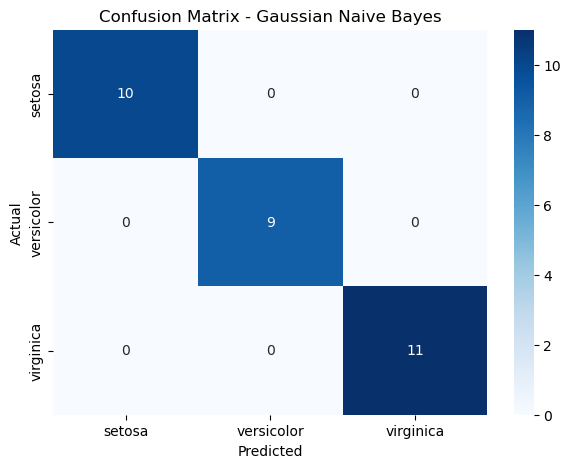

In [19]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm_gaussian,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=gnb_model.classes_,
    yticklabels=gnb_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.show()

Multinomial Naive Bayes

In [20]:
# Create Multinomial Naive Bayes Model

mnb_model = MultinomialNB()

# Train Model

mnb_model.fit(X_train, y_train)

print("\nMultinomial Naive Bayes Model Trained Successfully")


Multinomial Naive Bayes Model Trained Successfully


In [21]:
# Predict Test Data

y_pred_multi = mnb_model.predict(X_test)

print("\nPredictions Made Using Multinomial Naive Bayes")


Predictions Made Using Multinomial Naive Bayes


In [22]:
accuracy_multi = accuracy_score(
    y_test,
    y_pred_multi
)

print("\n===================================")

print("Multinomial Naive Bayes Accuracy :",
      accuracy_multi * 100,
      "%")

print("===================================")


Multinomial Naive Bayes Accuracy : 90.0 %


In [23]:
print("\nMultinomial Naive Bayes Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_multi
))


Multinomial Naive Bayes Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.75      1.00      0.86         9
   virginica       1.00      0.73      0.84        11

    accuracy                           0.90        30
   macro avg       0.92      0.91      0.90        30
weighted avg       0.93      0.90      0.90        30



In [24]:
cm_multi = confusion_matrix(
    y_test,
    y_pred_multi
)

print("\nConfusion Matrix:\n")

print(cm_multi)


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  3  8]]


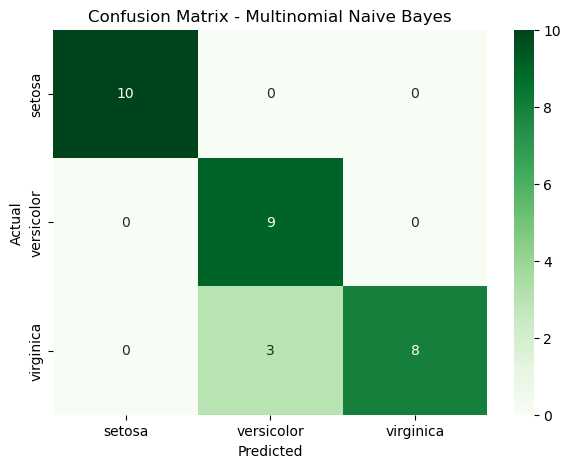

In [25]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=mnb_model.classes_,
    yticklabels=mnb_model.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

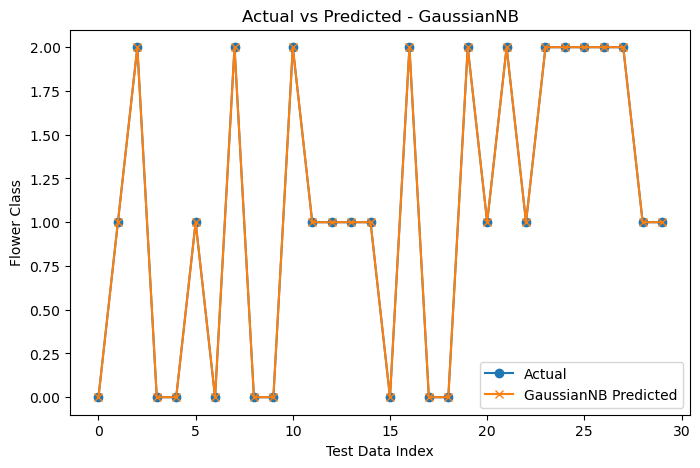

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(len(y_test)),
    pd.factorize(y_test)[0],
    label='Actual',
    marker='o'
)

plt.plot(
    range(len(y_pred_gaussian)),
    pd.factorize(y_pred_gaussian)[0],
    label='GaussianNB Predicted',
    marker='x'
)

plt.xlabel("Test Data Index")

plt.ylabel("Flower Class")

plt.title("Actual vs Predicted - GaussianNB")

plt.legend()

plt.show()

In [27]:
print("\n========== MODEL COMPARISON ==========\n")

print("Gaussian Naive Bayes Accuracy     :",
      accuracy_gaussian * 100,
      "%")

print("Multinomial Naive Bayes Accuracy  :",
      accuracy_multi * 100,
      "%")


========== MODEL COMPARISON ==========

Gaussian Naive Bayes Accuracy     : 100.0 %
Multinomial Naive Bayes Accuracy  : 90.0 %
